## Contents
1. **Data Overview** <br> _Outlook on Raw Data._
2. **Data Wrangling** <br> _Data Cleaning<br>Train / Test Split<br>Statistical Interference<br>Correlations<br>_
3. **Machine Learning with sklearn** <br> _ML Setup<br>Training<br>Training Performance<br>_
4. **Prediction Performance Summary** <br> _Best ML model (specification)<br>Evaluation<br>Threshold Tuning._

In [1]:
# Linear algebra and data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
%matplotlib inline

# Preprocessing
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import KBinsDiscretizer

# Statistical interference
from scipy.stats import mannwhitneyu

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Model selection
from sklearn.model_selection import train_test_split, GridSearchCV

# Pipelining
from sklearn.pipeline import make_pipeline

# metrics
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, auc, roc_curve

# 1) Data overwiev

Function `columns_info()`, indicating features' basic metadata and descriptive statistics for a given df, is defined in order to facilitate analysis.

In [2]:
def columns_info(df):
    # features' basic metadata and descriptive statistics for a given df
    feature_info = {
        'feature': [],
        'dtype': [],
        'nunique': [],
        'min': [],
        '25%': [],
        '50%': [],
        '75%': [],
        'max': [],
        'mean': [],
        'std_dev': []
        }

    for col in df.columns:
        feature_info['feature'].append(col)
        feature_info['dtype'].append(df[col].dtype)
        feature_info['nunique'].append(len(df[col].unique()))
        if df[col].dtype=='object':
            feature_info['min'].append(np.nan)
            feature_info['25%'].append(np.nan)
            feature_info['50%'].append(np.nan)
            feature_info['75%'].append(np.nan)
            feature_info['max'].append(np.nan)
            feature_info['mean'].append(np.nan)
            feature_info['std_dev'].append(np.nan)
        else:
            feature_info['min'].append(df[col].min())
            feature_info['25%'].append(df[col].quantile(0.25))
            feature_info['50%'].append(df[col].median())
            feature_info['75%'].append(df[col].quantile(0.75))
            feature_info['max'].append(df[col].max())
            feature_info['mean'].append(df[col].mean())
            feature_info['std_dev'].append(df[col].std())

    features = pd.DataFrame(feature_info)
    features.set_index('feature', inplace=True)
    return features

## Outlook on Raw Data

In [3]:
df = pd.read_csv('/kaggle/input/anonymous-data/or_data.csv')
df.sample(5)

,YEAR,Y,R1,R2,R3,R4,R5,R6,R7,R8,R9,R10,R11,R12,R13,R14,R15,R16
682,2016,1,4.445,7.685,3.871,0.615,0.692,1.125,1.293,2.234,1.0,0.070,0.070,0.873,0.061,0.042,0.602,0.042
205,2013,1,0.278,0.540,0.115,0.336,0.247,0.735,-0.864,3.452,1.0,0.003,0.003,0.005,0.357,0.088,30.816,0.088
1084,2014,0,-0.296,-0.402,-0.192,0.225,0.602,2.670,0.766,5.603,-1.0,0.056,-0.056,0.100,-0.405,-0.244,4.351,0.244
325,2013,1,3.318,3.271,1.243,0.805,0.541,0.672,0.968,1.768,1.0,0.003,0.003,0.014,0.187,0.101,29.009,0.101
80,2018,0,0.394,0.435,0.003,0.178,0.042,0.236,-0.182,32.698,1.0,1.020,1.020,2.487,-1.613,-0.068,-0.067,-0.068


In [4]:
# object dtypes despite only apparent numbers
print(f'Number of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')
print(f'Data types: {set(df.dtypes.values)}')
print(f'Missing values: {df.isnull().values.any()}')
print(f"Duplicates: {df.duplicated().sum()}")

Number of rows: 1120
Number of columns: 18
Data types: {dtype('float64'), dtype('O'), dtype('int64')}
Missing values: False
Duplicates: 225


Descriptive statistics indicate the presence of outliers in the distribution of features.

In [5]:
# dtypes conversion
pd.set_option('mode.chained_assignment', None)
for col in df.columns:
    if df[col].dtype == object:
        df = df[~(df[col].str.contains(','))]
        df[col] = df[col].astype('float')
        
# features info
pd.set_option('display.float_format', lambda x: '%.2f' % x)
features = columns_info(df)
features

,dtype,nunique,min,25%,50%,75%,max,mean,std_dev
feature,,,,,,,,,
YEAR,int64,8,2011.00,2012.00,2015.00,2017.00,2018.00,2014.51,2.30
Y,int64,2,0.00,0.00,1.00,1.00,1.00,0.65,0.48
R1,float64,743,-11.16,0.53,1.00,1.80,223.49,2.73,13.41
R2,float64,778,-0.88,0.78,1.35,2.29,224.69,3.12,13.45
R3,float64,525,-0.35,0.04,0.16,0.61,138.60,0.90,5.42
R4,float64,563,0.00,0.34,0.60,0.80,41.40,0.64,1.76
R5,float64,617,-0.37,0.16,0.39,0.78,118.34,0.70,3.61
R6,float64,690,-1.69,0.37,0.73,1.42,601.22,2.38,23.37
R7,float64,797,-361.62,-0.08,0.91,2.95,423.66,2.74,29.86


In [6]:
# target distribution
df['Y'].value_counts(normalize=True)

Y
1   0.65
0   0.35
Name: proportion, dtype: float64

# 2) Data Wrangling

## Data Cleaning

In [7]:
df.shape

(1105, 18)

In [8]:
# zero-only rows exclusion
excluded_from_zero_check_columns = ['YEAR', 'Y']
mask = ~(df.drop(columns=excluded_from_zero_check_columns) == 0).all(axis=1)
df = df[mask]

# duplicates removal
df.drop_duplicates(inplace=True)

In [9]:
# target distribution
df['Y'].value_counts(normalize=True)

Y
1   0.67
0   0.33
Name: proportion, dtype: float64

In [10]:
df.shape

(878, 18)

## Train / Test Split

In [11]:
y = df['Y']
X = df.drop('Y', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=df['Y'])

In [12]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((702, 17), (702,), (176, 17), (176,))

In [13]:
# the target is stratified 
y_test.value_counts(normalize=True)

Y
1   0.67
0   0.33
Name: proportion, dtype: float64

## Statistical Interference
Since the target is binary, we can split the data into two groups based on the target variable and use the Mann-Whitney U test to determine if the distributions of your continuous or ordinal feature differ significantly between these two groups. The Mann-Whitney U test is a non-parametric test that compares the distributions of two independent groups. It does not assume normal distribution, making it appropriate for continuous or ordinal data, especially when the assumption of normality is not met.

In [14]:
X_train.shape

(702, 17)

In [15]:
df_train = pd.concat([X_train, y_train], axis=1)

for feature in X_train.columns:
    group_0 = df_train[df_train['Y']==0][feature]
    group_1 = df_train[df_train['Y']==1][feature]
    stat, p = mannwhitneyu(group_0, group_1, alternative='two-sided')
    if p < 0.05:
        print('{} is statistically significant.'.format(feature))
    else:
        X_train = X_train.drop(feature, axis=1)
        X_test = X_test.drop(feature, axis=1)
        df_train = df_train.drop(feature, axis=1)

R1 is statistically significant.
R2 is statistically significant.
R3 is statistically significant.
R4 is statistically significant.
R5 is statistically significant.
R6 is statistically significant.
R7 is statistically significant.
R13 is statistically significant.
R14 is statistically significant.
R15 is statistically significant.
R16 is statistically significant.


In [16]:
X_train.shape

(702, 11)

## Correlations

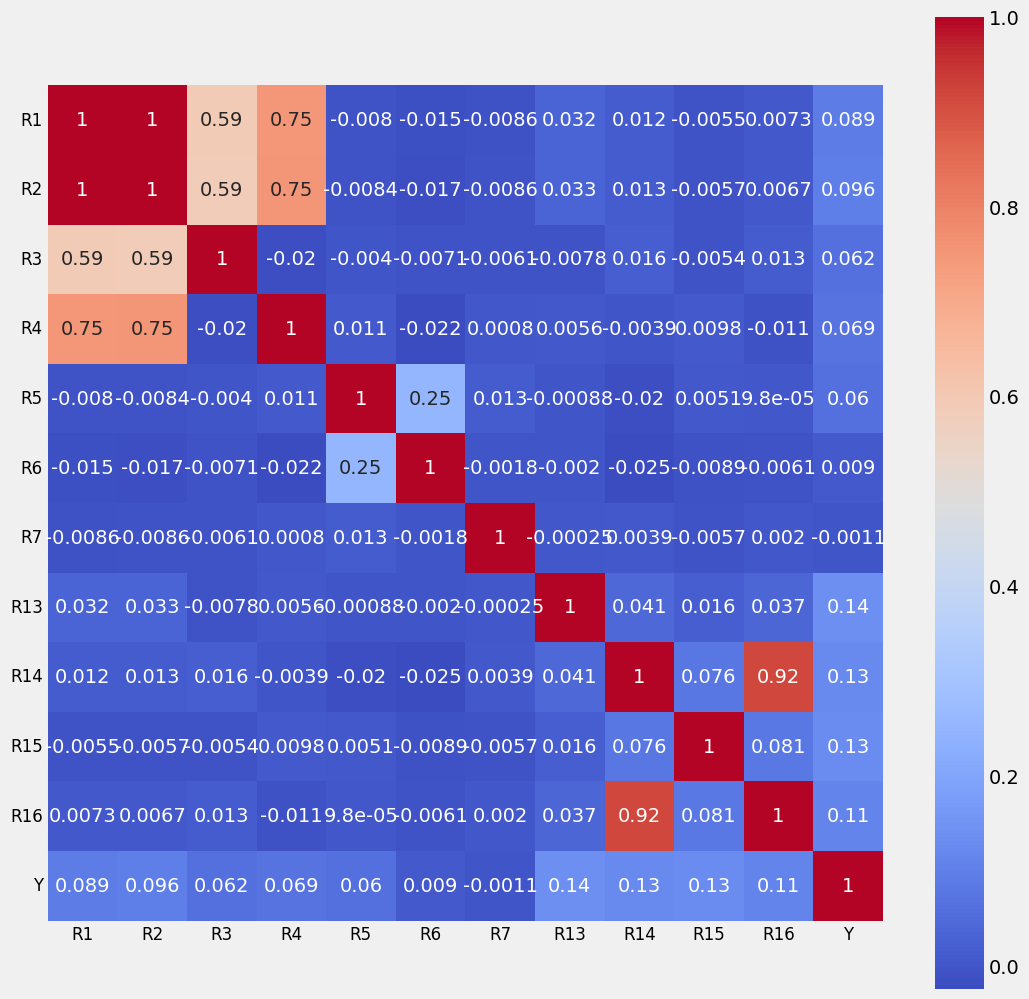

In [17]:
# Pearson coeff heatmap
plt.figure(figsize=(12, 12))
sns.heatmap(df_train.corr(), annot=True, square=True, cmap='coolwarm')
plt.tick_params(axis='x', labelsize=12, rotation=0)
plt.tick_params(axis='y', labelsize=12, rotation=0)
plt.show()

In [18]:
# Colinear features exclusion
X_train.drop(columns=['R1', 'R16'], inplace=True)
X_test.drop(columns=['R1', 'R16'], inplace=True)

# 3) Machine Learning with sklearn
Following classifiers are GridSearched in effort to find the best suited model:
* `LogisticRegression`
* `RandomForestClassifier`
* `KNeighborsClassifier`

## ML setup
To mitigate outliers in the training data, `KBinsDiscretizer` is applied. To address the imbalanced target distribution, the hyperparameter `class_weight='balanced'` is used (where possible).

In [19]:
prep = make_column_transformer((KBinsDiscretizer(n_bins=10, encode='ordinal',  strategy='quantile'), X_train.columns))

pipelines = {
    'logreg':make_pipeline(prep, LogisticRegression(class_weight='balanced')),
    'forest':make_pipeline(prep, RandomForestClassifier(class_weight='balanced')),
    'knn':make_pipeline(prep, KNeighborsClassifier())  
    }

hypergrid = {
    'logreg': {
        'logisticregression__C':[1.4, 2, 2.6, 4, 5.7, 7.8],
        'logisticregression__solver':['lbfgs', 'liblinear']
    },
    'forest': {
        'randomforestclassifier__n_estimators':[24, 46, 52, 73, 100, 130, 165],
        'randomforestclassifier__criterion':['gini', 'entropy'],
        'randomforestclassifier__min_samples_leaf':[1, 4, 8]
    },
    'knn': {
        'kneighborsclassifier__n_neighbors':list(range(160, 220, 5)),
        'kneighborsclassifier__weights':['uniform', 'distance']
    }
    }

## Training

In [20]:
%%time
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

models_acc = {}
models_auc = {}
for algo, pipeline in pipelines.items():
    model_acc = GridSearchCV(pipeline, hypergrid[algo], cv=10, scoring='accuracy')
    model_auc = GridSearchCV(pipeline, hypergrid[algo], cv=10, scoring='roc_auc')
    model_acc.fit(X_train,y_train)
    model_auc.fit(X_train,y_train)
    models_acc[algo] = model_acc
    models_auc[algo] = model_auc

CPU times: user 3min 3s, sys: 1.32 s, total: 3min 5s
Wall time: 3min 5s


## Training performance

In [21]:
train_results = pd.DataFrame(columns=['ACC', 'AUC'])

for algo in models_acc.keys():
    train_results.loc[algo] = [models_acc[algo].best_score_, models_auc[algo].best_score_]
    
train_results.sort_values(by='AUC', ascending=False)

,ACC,AUC
forest,0.90,0.93
knn,0.87,0.91
logreg,0.84,0.89


# 4) Prediction performance summary

In [22]:
test_results = pd.DataFrame(columns=['ACC', 'AUC'])

for algo in models_acc.keys():
    y_pred_acc = models_acc[algo].predict(X_test)
    y_pred_auc = models_auc[algo].predict_proba(X_test)[:, 1]
    test_results.loc[algo] = [accuracy_score(y_test, y_pred_acc), roc_auc_score(y_test, y_pred_auc)]
    
test_results.sort_values(by='AUC', ascending=False)

,ACC,AUC
forest,0.90,0.94
knn,0.89,0.92
logreg,0.82,0.92


## Best Model (specification)

In [23]:
models_auc['forest']

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('kbinsdiscretizer',
                                                                         KBinsDiscretizer(encode='ordinal',
                                                                                          n_bins=10),
                                                                         Index(['R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R13', 'R14', 'R15'], dtype='object'))])),
                                       ('randomforestclassifier',
                                        RandomForestClassifier(class_weight='balanced'))]),
             param_grid={'randomforestclassifier__criterion': ['gini',
                                                               'entropy'],
                         'randomforestclassifier__min_samples_leaf': [1, 4, 8],
                         'randomforestclassifier__n_estimators': [24, 46, 52,
                                                                  73, 100, 130,
                                                                  165]},
             scoring='roc_auc')

In [24]:
models_auc['forest'].best_params_

{'randomforestclassifier__criterion': 'gini',
 'randomforestclassifier__min_samples_leaf': 1,
 'randomforestclassifier__n_estimators': 100}

## Evaluation
A good starting point for evaluating a classifier is the `confusion matrix`. The confusion matrix provides a detailed breakdown of the classifier's performance across all classes. It also serves as a basis for deeper analysis and subsequent metrics, like:
* `Accuracy`: Provides a general overview of the model’s performance but does not indicate how well each individual class is performing.
* `Sensitivity`: Measures the proportion of actual positive cases correctly identified by the model. It reflects the model’s ability to detect positive instances, also known as the true positive rate.
* `Specificity`: Measures the proportion of actual negative cases correctly identified by the model. It reflects the model’s ability to identify negative instances, also known as the true negative rate.

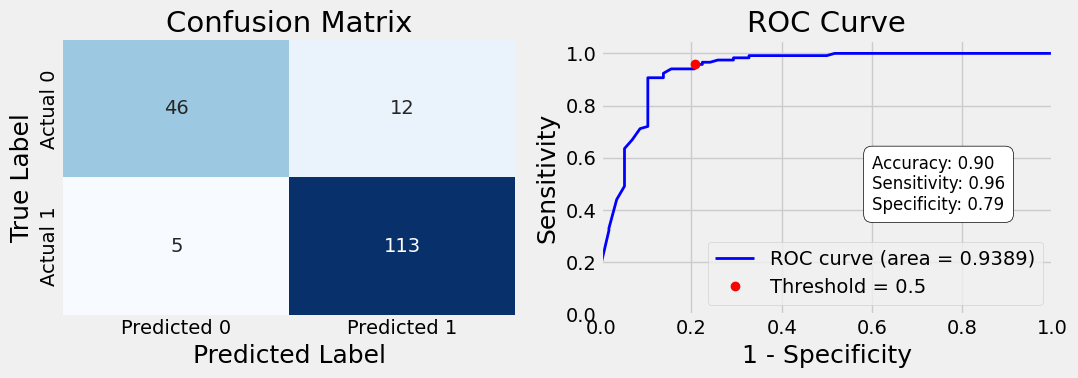

In [25]:
# Compute confusion matrix
cm = confusion_matrix(y_test, models_auc['forest'].predict(X_test))

# Compute ROC curve and AUC
y_pred_proba = models_auc['forest'].predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Compute accuracy, sensitivity and specificity
accuracy = (cm[0, 0] + cm[1, 1]) / np.sum(cm)
default_threshold_index = np.where(thresholds > 0.5)[0][-1]
sensitivity = tpr[default_threshold_index]
specificity = 1 - fpr[default_threshold_index]

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Confusion Matrix subplot
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues', 
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'], 
            cbar=False, 
            ax=axes[0])

axes[0].set_title('Confusion Matrix', fontsize=21)
axes[0].set_xlabel('Predicted Label', fontsize=18)
axes[0].set_ylabel('True Label', fontsize=18)
axes[0].tick_params(axis='both', which='major', labelsize=14)

# ROC Curve subplot
axes[1].plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
axes[1].legend(loc="lower right", fontsize=14)
axes[1].text(0.6, 0.4, f'Accuracy: {accuracy:.2f}\nSensitivity: {sensitivity:.2f}\nSpecificity: {specificity:.2f}', 
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'), 
             fontsize=12)
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('1 - Specificity', fontsize=18)
axes[1].set_ylabel('Sensitivity', fontsize=18)
axes[1].set_title('ROC Curve', fontsize=21)
axes[1].plot(fpr[default_threshold_index], tpr[default_threshold_index], 'ro', label='Threshold = 0.5')
axes[1].legend(loc="lower right", fontsize=14)

plt.tight_layout()
plt.show()

**ROC Curve**

The ROC Curve (Receiver Operating Characteristic curve) is essentially a tool for visualizing trade-off between sensitivity and specificity. The trade-off between sensitivity and specificity often arises because adjusting the classification threshold can improve one metric at the expense of the other.

## Threshold Tuning
The ROC curve plot suggests that, if we give equal weight to both specificity and sensitivity, we can adjust the classifier's threshold for better balance.

In [26]:
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

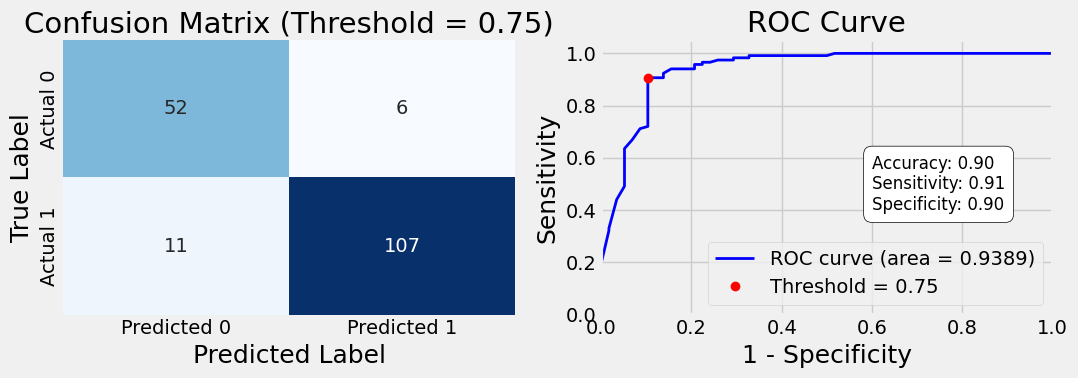

In [27]:
# Compute predicted probabilities
y_pred_proba = models_auc['forest'].predict_proba(X_test)[:, 1]

# Apply the optimal threshold to get the predictions
y_pred_adjusted = (y_pred_proba >= optimal_threshold).astype(int)

# Compute confusion matrix with the new threshold
cm = confusion_matrix(y_test, y_pred_adjusted)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Compute accuracy, sensitivity and specificity with the new threshold
accuracy = (cm[0, 0] + cm[1, 1]) / np.sum(cm)
optimal_threshold_index = np.where(thresholds >= optimal_threshold)[0][0]
sensitivity = tpr[optimal_idx]
specificity = 1 - fpr[optimal_idx]

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Confusion Matrix subplot
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues', 
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'], 
            cbar=False, 
            ax=axes[0])

axes[0].set_title(f'Confusion Matrix (Threshold = {optimal_threshold:.2f})', fontsize=21)
axes[0].set_xlabel('Predicted Label', fontsize=18)
axes[0].set_ylabel('True Label', fontsize=18)
axes[0].tick_params(axis='both', which='major', labelsize=14)

# ROC Curve subplot
axes[1].plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
axes[1].legend(loc="lower right", fontsize=14)
axes[1].text(0.6, 0.4, f'Accuracy: {accuracy:.2f}\nSensitivity: {sensitivity:.2f}\nSpecificity: {specificity:.2f}', 
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'), 
             fontsize=12)
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('1 - Specificity', fontsize=18)
axes[1].set_ylabel('Sensitivity', fontsize=18)
axes[1].set_title('ROC Curve', fontsize=21)
axes[1].plot(fpr[optimal_idx], tpr[optimal_idx], 'ro', label=f'Threshold = {optimal_threshold:.2f}')
axes[1].legend(loc="lower right", fontsize=14)

plt.tight_layout()
plt.show()

``AUC`` (Area Under the ROC Curve) is a threshold-agnostic metric, providing a synthetic measure of classifier's overall ability to distinguish between classes.